# A note regarding citation ethics
### Self-citation
This project heavily relies on the previous works by the author **Kiana Jafari**.

#### References:
- **Mathematics**: <a href='https://medium.com/@Kiana-Jafari/understanding-the-math-behind-deep-neural-networks-602b7b6a150a'>Article Published on Medium</a>
- **Coding**: <a href='https://github.com/Kiana-Jafari/Handwritten-Digit-Recognition'>Notebook for Educational and Replicating Research Purposes</a>

### 1. Importing Packages
We begin the process by importing the esential 

In [1]:
# Import packages and libraries
from methods import (
    initialize_parameters, forward_propagation, 
    compute_cost, backward_propagation,
    initialize_adam, update_parameters
    )

from preprocess import (
    separate_data, scale_features, 
    transpose_data, one_hot_encode_target
    )

from utils import get_shapes

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    confusion_matrix, 
    classification_report,
    ConfusionMatrixDisplay
    )

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### 2. Loading the Dataset
Read and load the scaled dataset using pandas and display a few rows.

In [2]:
# Load in the data
data = pd.read_csv('breast_cancer.csv')

# Display a few rows
data.head()

,worst smoothness,mean radius,target
0,0.1622,17.99,0
1,0.1238,20.57,0
2,0.1444,19.69,0
3,0.2098,11.42,0
4,0.1374,20.29,0


As we saw in the previous notebook, the two variables (features), namely, `worst fractal dimension` and `mean radius`, were the two most correlated features based on the data analysis and feature selection that we did. (i.e., Plotting a heatmap, computing the pearson correlation between target-features, and displaying multicollinearity between features-features.

### 3. Data Splitting
In machine learning, before any implementation phases, we should begin the process by splitting the whole data into two subsets, namely, `training set` & `testing set` (sometimes we also tend to split the test set into another `validation set` as well. This is mainly used for testing the model performance during the training phase). This is a common way for any ML models, to not only train the model, but also test and validate its performance with the associated true labels that we have for each of the data points in the test set.

Remember that we had a class imbalance in the target. So, we should take it into consideration.

In [3]:
# Check again for the class imbalance (target)
data['target'].value_counts(normalize=True)

target
1    0.627417
0    0.372583
Name: proportion, dtype: float64

One way to deal with this issue is to `stratify` the target in train-test-split. This can be done using `train_test_split()` from the sklearn library.

But before any preprocessing steps, separate data into `features` and `target`.

In [4]:
# Separate target from the features
features, target = separate_data(data)

In [5]:
# Display separated data
print('Features:\n', features.head())
print()
print('Target:\n', target[:5])

Features:
    worst smoothness  mean radius
0            0.1622        17.99
1            0.1238        20.57
2            0.1444        19.69
3            0.2098        11.42
4            0.1374        20.29

Target:
 0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64


In [6]:
# Split the training data into training and validation sets
X_train, X_test, y_train, y_test = train_test_split(
    features, 
    target, 
    test_size=0.1,
    random_state=42,
    stratify=target)

In [7]:
# Get shape of each training, and testing set
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((512, 2), (512,), (57, 2), (57,))

#### 3.1 Data Preprocessing

This task will follow in general the following steps:
1. Feature Scaling
2. Data Transpose
3. One-Hot Encoded

##### 3.1 Feature Scaling
Now, let's move to the next section, where we have different ranges for the two features. As shown below, the values for the column `worst fractal dimension` fall in a far greater range than the `mean radius` column. So, we may want to scale them to fall in a more suitable range.
To better understand what this means, consider the max value for the column `worst fractal dimension` which has a value of 0.12. Now, consider the max of the column `mean radius` which is about 22. How different are these two values? About 0.12, which is too high.

##### So what's the solution?
There are several scaling methods that let us scale the values so that comparing two columns would be easier. The one we're going to use is called `Standardization` which uses the following formula:

$x_{scaled} = \frac{x - x_{min}}{x_{max} - x_{min}}$

split</br>
↓</br>
fit scaler on X_train</br>
↓</br>
transform X_train / X_test</br>
↓</br>
transpose

In [8]:
# Scale the X_train & X_test
X_train, X_test = scale_features(X_train, X_test)

In [9]:
# Convert data to NumPy array and transpose for easier manipulation
X_train = transpose_data(X_train)
X_test = transpose_data(X_test)

# Get the new shape of the two sets
print(f'Shape of X_train after transpose: {X_train.shape}\n'
      f'Shape of X_test after transpose: {X_test.shape}')

Shape of X_train after transpose: (2, 512)
Shape of X_test after transpose: (2, 57)


In [10]:
# One-Hot Encode y_train and y_test
y_train = one_hot_encode_target(y_train)
y_test = one_hot_encode_target(y_test)

In [11]:
# Transpose labels
y_train = transpose_data(y_train)
y_test = transpose_data(y_test)

# Display shapes of labels
print(f'Shape of y_train after preprocessing: {y_train.shape}\n'
      f'Shape of y_test after preprocessing: {y_test.shape}')

Shape of y_train after preprocessing: (2, 512)
Shape of y_test after preprocessing: (2, 57)


**NOTE:** **Do not** get confused with the outputs. The output of the two preprocessed sub-sets is the same. We have two features for the training and testing sets, and also two classes as the labels of the target. Thus, we get a shape of (2, m)

### 4. Model Implementation
Implementing and deploying the model is probably one of the most (if not the most) interesting parts of the PACE strategy, which stands for, `Plan`, `Analyze`, `Construct`, `Execute`. These are important steps when dealing with project life cycle.

#### 4.1 Understanding the Network Architecture
Understanding the network design/architecture is as important as building the model. In this project, for the sake of simplicity, we're going to build a `shallow neural network`.
In a shallow neural network, there is only **one hidden layer** between the input and output layers. The number of hidden layers is a hyperparameter and a measurement of the depth of a neural network.

#### 4.2 Neural Network

A neural network or neural net, also known as an artificial neural network, is a computational model inspired by the structure and functions of biological neural networks. A neural network consists of connected units or nodes called artificial neurons, which loosely model the neurons in the brain.

The number of neurons in the input layer equals the `number of input variables in the data being processed` (in our case 2). The number of neurons in the output layer equals the number of outputs associated with each input.

> Now, given these explanations, the question is, what is our **"n-layer network"**? In other words, how many layers should the network have? 

To answer this question, we should consider one point: In typical neural network terminology, when someone says an "n-layer network" (e.g., 2‑layer, 3‑layer), they do not count the input layer. The input layer simply passes data in; no weights, biases, or activation functions are applied there — so it's not considered a “processed” layer.

Apply this to our case:

For a network with the 2 → 4 → 2 architecture:
- Hidden layer (4 neurons) → layer 1
- Output layer (2 neurons) → layer 2

That makes it a **2‑layer network** (one hidden + one output).

> Number of layers in the network = total layers with trainable parameters (hidden + output).
Input layer is **excluded**.

#### 4.3 Activation Function
In artificial neural networks, the activation function of a node is a function that calculates the output of the node based on its individual inputs and their weights. Activation functions are an integral building block of neural networks that enable them to learn complex and non-linear patterns in data. They transform the input signal of a node in a neural network into an output signal that is then passed on to the next layer.

Without activation functions the input will be merely a linear equation which transforms no complex relationship 
(i.e., $z = wx + b$). An activation function adds complexity and pattern recognition ability to these inputs by applying some thresholds and criteria.

##### 4.3.1 ReLU

ReLU can be named as one of the simplest activation functions with the following formula:

$$
\text{ReLU}(x) = \max(0, x) = 
\begin{cases} 
x & \text{if } x > 0 \\
0 & \text{if } x \le 0 
\end{cases}
$$

It has a very interesting property, which makes it easy-to-use, and that is its derivative:

$$
\text{ReLU Derivative}(x) = 
\begin{cases} 
1 & \text{if } x > 0 \\
0 & \text{if } x \le 0 
\end{cases}
$$

> **For those interested in Math**: The derivative of x, a linear function with respect to x is `1`, a constant.

##### 4.3.2 Softmax
The two activation functions that are going to be used in this project are `ReLU` for hidden layer and `Softmax` for the output layer.

---

For an input vector $\mathbf{z} = [z_1, z_2, \dots, z_K]$, the softmax function $\sigma: \mathbb{R}^K \to [0,1]^K$ is defined as:

$$
\sigma(\mathbf{z})_i = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}} \quad \text{for } i = 1, 2, \dots, K
$$

The output is a probability distribution (all values positive and sum to 1).

### 4.4 Parameter Initialization
The neural network's parameters (weights and biases) are initialized before training begins. This process of initialization involves setting random starting values for the parameters, which are then adjusted during training in order to improve the network's performance.

Weights are going to be set to a small random number, whereas biases are set as zeros.

The reason behind multiplying weights by a small constant is to ensure that the weights of the function are not only randomized but also relatively small in order not to affect the training process.

### 4.5 Feed Forward Neural Network
During forward propagation, input data is passed through the network layers, and activations are computed using the initialized parameters and activation functions.

### 4.6 Cost Function
Cost function quantifies the disparity between predicted outputs and ground truth labels, and serves as a metric to evaluate the model's performance.
For the purpose of `Backpropagation`, we need to first derive from this equation.

Note that we are using a regularization term "L2-norm"; so we need to mention the term in our cost formula as well.

For a batch of $m$ examples, the **regularized cost** $J_{\text{reg}}$ is the average loss plus an L2 penalty on the weights:

$Cost = - \frac{1}{m}\sum_{i=1}^{m}\sum_{k=1}^{n}[ y_k \log(a_k) ] + \frac{\lambda}{2m} \sum_{j=1}^{p} w_j^2$

Bias terms are typically **not** regularized.

The L2 term penalizes large weights, encouraging simpler models and reducing overfitting.

### 4.7 Backpropagation
During the training of a neural network, the backpropagation algorithm is used to calculate the gradients of the loss function with respect to each parameter in the network. These gradients are then used to update the parameters in the network, which ultimately leads to an improvement in the network's ability to make accurate predictions. The backpropagation algorithm works by computing the derivatives of the loss function with respect to each weight in the network, and then propagating these derivatives backwards through the network to update the weights. This process is repeated many times during training, gradually improving the network's performance until it reaches a satisfactory level.

### 4.8 Adam Optimization
Our network uses `Adam` as the optimizer, which is indeed much faster than the traditional SGD + Momentum.

The Adam algorithm uses adaptive learning rates to update network parameters efficiently, which allows it to converge faster than other optimization algorithms.

### 4.9 Updating parameters with Adam
Adam is considered one of the most effective and capable optimization algorithms for training neural networks. It combines ideas from RMSProp and Momentum to improve performance.

The algorithm applies individual learning rates to each parameter and adapts the updates based on the accumulated past gradients and squared gradients.

In addition, bias-correction term is considered into the algorithm to prevent the optimization process from becoming trapped in local minima.

alongside Adam Optimizer and Mini-Batch Gradient Descent, we will use another commonly used technique called `Learning Rate Decay`. This is the process of gradually reducing the learning rate at each step. It prevents the model, not to overshoot the optima.

### 5. Evaluating the Network
The network is trained using mini-batch gradient descent with Adam optimization. Training involves iterating over the dataset for a specified number of epochs, computing forward and backward passes, and updating network parameters.

In [12]:
class NeuralNetwork:

    def __init__(self, learning_rate, decay_rate, penalty, iterations, hidden_size=4):

        self.learning_rate = learning_rate
        self.decay_rate = decay_rate
        self.penalty = penalty
        self.iterations = iterations
        self.hidden_size = hidden_size

    def fit(self, X, y):
        
        # Store the cost of the training set
        train_cost_history = []

        # Retrieve arguments
        input_size, output_size = get_shapes(X, y)

        self.parameters = initialize_parameters(input_size, self.hidden_size, output_size)
        self.velocity, self.cache = initialize_adam(self.parameters)

        for epoch in range(self.iterations):

            epoch_cost = 0 # Initialize the cost for the training set

            # Compute forwardpropagation
            a2, self.forward_cache = forward_propagation(X, self.parameters)

            # Compute training cost
            cost = compute_cost(a2, y, self.parameters, self.penalty)
            epoch_cost += cost
            
            # Backpropagation
            gradients = backward_propagation(
                X, y, self.parameters, 
                self.forward_cache, self.penalty
            )

            # Updating
            self.parameters, self.velocity, self.cache = update_parameters(
                self.parameters, gradients,
                self.velocity, self.cache,
                self.learning_rate, self.decay_rate,
                epoch
            )
            
            # Append cost and display every 10 iterations
            epoch_cost /= len(X)
            train_cost_history.append(epoch_cost)

            if epoch % 10 == 0:
                print(f'Epoch {epoch}: Train Cost = {epoch_cost:.4}')

        return self.parameters, self.forward_cache, train_cost_history


    def predict(self, X):
        a2, _ = forward_propagation(X, self.parameters)
        return np.argmax(a2, axis=0)  # Get the prediction with the highest probability               
            

In [13]:
# Initialize the hyperparameters
learning_rate = 0.005
decay_rate = 0.0005
penalty = 0.0005
num_epochs = 350

In [14]:
# Train the network
ann = NeuralNetwork(learning_rate, decay_rate, penalty, num_epochs)

# Retrieve the trained parameters
trained_parameters, forward_cache, train_cost_history = ann.fit(X_train, y_train)

Epoch 0: Train Cost = 0.1733
Epoch 10: Train Cost = 0.1665
Epoch 20: Train Cost = 0.1557
Epoch 30: Train Cost = 0.1421
Epoch 40: Train Cost = 0.1268
Epoch 50: Train Cost = 0.1119
Epoch 60: Train Cost = 0.09913
Epoch 70: Train Cost = 0.08889
Epoch 80: Train Cost = 0.08094
Epoch 90: Train Cost = 0.07478
Epoch 100: Train Cost = 0.06992
Epoch 110: Train Cost = 0.06601
Epoch 120: Train Cost = 0.06281
Epoch 130: Train Cost = 0.06017
Epoch 140: Train Cost = 0.05795
Epoch 150: Train Cost = 0.05607
Epoch 160: Train Cost = 0.05445
Epoch 170: Train Cost = 0.05306
Epoch 180: Train Cost = 0.05185
Epoch 190: Train Cost = 0.05078
Epoch 200: Train Cost = 0.04984
Epoch 210: Train Cost = 0.049
Epoch 220: Train Cost = 0.04826
Epoch 230: Train Cost = 0.04759
Epoch 240: Train Cost = 0.04699
Epoch 250: Train Cost = 0.04644
Epoch 260: Train Cost = 0.04595
Epoch 270: Train Cost = 0.0455
Epoch 280: Train Cost = 0.04509
Epoch 290: Train Cost = 0.04471
Epoch 300: Train Cost = 0.04437
Epoch 310: Train Cost = 0.04

### 6. Plotting the Training Cost Function
Within the following function, we will generate a visual representation of the performance of the Cost Function. This will include the Training phase.

In [15]:
def plot_cost_graph(train_cost_history):

    # Plot the cost in each iteration (loss)
    sns.set_theme(style='darkgrid')
    train_iterations = len(train_cost_history)
    plt.figure(figsize=(15, 6))
    plt.plot(range(train_iterations), train_cost_history, label='Training Cost', color='blue')
    plt.title('Cost vs. Iterations')
    plt.xlabel('Iterations')
    plt.ylabel('Cost')
    plt.grid(True)
    plt.legend()
    plt.show();

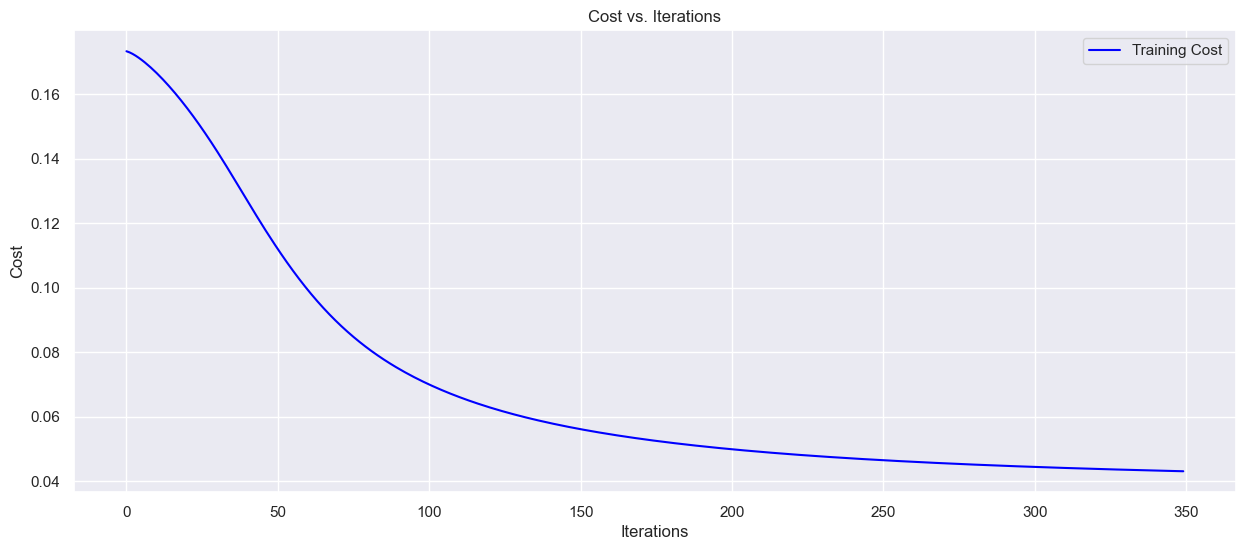

In [16]:
# Plot cost history
plot_cost_graph(train_cost_history)

### 7. Predictions and Evaluation Metrics
We would consider `Accuracy` as the Evaluation Metrics.

To calculate accuracy, first, make predictions on the validation-test data, and then, use the corresponding ground truth to calculate the proportion of true predicted images by the model.

In [17]:
def accuracy_score(prediction, label):

    # Calculate the proportion of corrected labels
    return np.mean(prediction == np.argmax(label, axis=0))

In [18]:
# Make predictions and evaluate accuracy
train_preds = ann.predict(X_train)
train_acc = accuracy_score(train_preds, y_train)

y_pred = ann.predict(X_test)
test_acc = accuracy_score(y_pred, y_test)

print(
    f'Training accuracy: {train_acc:.4}\n'
    f'Testing accuracy: {test_acc:.4}')

Training accuracy: 0.9375
Testing accuracy: 0.9298


### 8. Analysis
How many wrong predictions are estimated by our model?

In [19]:
# Identify indices of incorrect predictions
incorrect_indices = np.where(y_pred != np.argmax(y_test, axis=0))[0]
incorrect_indices

array([ 2,  5, 40, 56])

4 errors among 57 test cases.

In [20]:
# Display the predictions vs. ground truth
m = y_test.shape[1]

for i in range(m):
    true_label = np.argmax(y_test[:, i])
    pred_label = y_pred[i]
    
    print(f"Sample {i:2d}: Pred = {pred_label}, True = {true_label}")

Sample  0: Pred = 0, True = 0
Sample  1: Pred = 1, True = 1
Sample  2: Pred = 1, True = 0
Sample  3: Pred = 0, True = 0
Sample  4: Pred = 0, True = 0
Sample  5: Pred = 0, True = 1
Sample  6: Pred = 0, True = 0
Sample  7: Pred = 1, True = 1
Sample  8: Pred = 1, True = 1
Sample  9: Pred = 1, True = 1
Sample 10: Pred = 1, True = 1
Sample 11: Pred = 0, True = 0
Sample 12: Pred = 0, True = 0
Sample 13: Pred = 0, True = 0
Sample 14: Pred = 1, True = 1
Sample 15: Pred = 0, True = 0
Sample 16: Pred = 1, True = 1
Sample 17: Pred = 1, True = 1
Sample 18: Pred = 1, True = 1
Sample 19: Pred = 1, True = 1
Sample 20: Pred = 0, True = 0
Sample 21: Pred = 1, True = 1
Sample 22: Pred = 1, True = 1
Sample 23: Pred = 1, True = 1
Sample 24: Pred = 0, True = 0
Sample 25: Pred = 1, True = 1
Sample 26: Pred = 1, True = 1
Sample 27: Pred = 1, True = 1
Sample 28: Pred = 0, True = 0
Sample 29: Pred = 1, True = 1
Sample 30: Pred = 1, True = 1
Sample 31: Pred = 0, True = 0
Sample 32: Pred = 1, True = 1
Sample 33:

### 9. Visualization

In [21]:
# Store the target names
target_names = ['malignant', 'benign']

Classification Report:
              precision    recall  f1-score   support

   malignant       0.90      0.90      0.90        21
      benign       0.94      0.94      0.94        36

    accuracy                           0.93        57
   macro avg       0.92      0.92      0.92        57
weighted avg       0.93      0.93      0.93        57

-----
Confusion Matrix:
[[19  2]
 [ 2 34]]


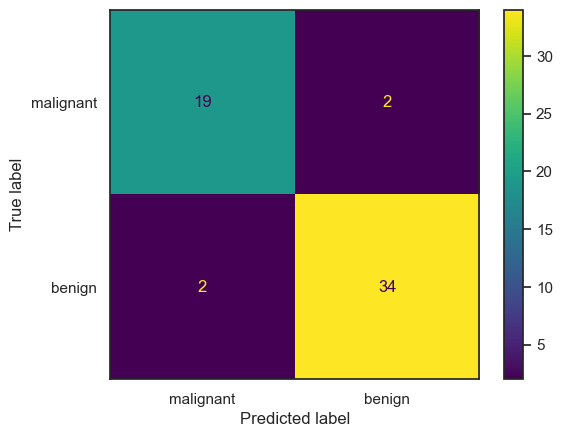

In [22]:
# Display confusion matrix and classification report
y_true = np.argmax(y_test, axis=0)

cm = confusion_matrix(y_true, y_pred)
cr = classification_report(y_true, y_pred, target_names=target_names)

print(f'Classification Report:\n{cr}')
print('-----')
print(f'Confusion Matrix:\n{cm}')

sns.set_theme(style='white')
disp = ConfusionMatrixDisplay(cm, display_labels=target_names)
disp.plot()
plt.show()

In [23]:
# Get the parameters, weighted sums, and the activations
W1 = trained_parameters['W1']
b1 = trained_parameters['b1']
W2 = trained_parameters['W2']
b2 = trained_parameters['b2']

Z1 = forward_cache['z1']
Z2 = forward_cache['z2']
A1 = forward_cache['a1']
A2 = forward_cache['a2']

In [24]:
print(
    f'W1:\n{W1}\n\n'
    f'b1:\n{b1}\n\n'
    f'W2:\n{W2}\n\n'
    f'b2:\n{b2}\n\n'
    f'Z1:\n{Z1}\n\n'
    f'Z2:\n{Z2}\n\n'
    f'A1:\n{A1}\n\n'
    f'A2:\n{A2}'
)

W1:
[[ 0.71994017  1.42198699]
 [ 0.62763396  1.41238795]
 [-0.86270678 -1.34458697]
 [ 0.05341917  0.04347016]]

b1:
[[ 1.00071732]
 [ 1.0831271 ]
 [ 0.52451656]
 [-0.05054898]]

W2:
[[ 1.3056249   1.30735086 -1.22512199 -0.03125485]
 [-1.30237071 -1.29277998  1.22304706  0.03952821]]

b2:
[[-0.26977257]
 [ 0.26977257]]

Z1:
[[ 0.29410309  1.28552111  0.11564895 ... -0.41004629  0.07742016
   0.12287412]
 [ 0.42496698  1.36948472  0.19591772 ... -0.25188936  0.15274332
   0.20498634]
 [ 1.28410488  0.2625262   1.34451788 ...  1.99709047  1.36978423
   1.34164314]
 [-0.08797759 -0.04314044 -0.07474957 ... -0.11765198 -0.07404184
  -0.07521118]]

Z2:
[[-0.90300901  2.87521668 -1.509048   ... -2.71485045 -1.64626515
  -1.48425388]
 [ 0.90749379 -2.85162347  1.50948926 ...  2.71070663  1.64590049
   1.48485676]]

A1:
[[0.29410309 1.28552111 0.11564895 ... 0.         0.07742016 0.12287412]
 [0.42496698 1.36948472 0.19591772 ... 0.         0.15274332 0.20498634]
 [1.28410488 0.2625262  1.34

In [25]:
print(
    f'X_train min & max: {(np.min(X_train), np.max(X_train))}',
    f'\nX_test min & max: {(np.min(X_test), np.max(X_test))}',
    f'\nW1 min & max: {(np.min(W1), np.max(W1))}',
    f'\nW2 min & max: {(np.min(W2), np.max(W2))}',
    f'\nb1 min & max: {(np.min(b1), np.max(b1))}',
    f'\nb2 min & max: {(np.min(b2), np.max(b2))}',
    f'\nZ1 min & max: {(np.min(Z1), np.max(Z1))}',
    f'\nZ2 min & max: {(np.min(Z2), np.max(Z2))}',
    f'\nA1 min & max: {(np.min(A1), np.max(A1))}',
    f'\nA2 min & max: {(np.min(A2), np.max(A2))}'
)

X_train min & max: (np.float64(-1.0), np.float64(1.0)) 
X_test min & max: (np.float64(-0.9262624828434852), np.float64(1.05705358962168)) 
W1 min & max: (np.float64(-1.344586970495573), np.float64(1.4219869870110824)) 
W2 min & max: (np.float64(-1.3023707063180374), np.float64(1.3073508571998216)) 
b1 min & max: (np.float64(-0.05054897504337046), np.float64(1.0831270953230994)) 
b2 min & max: (np.float64(-0.26977256550467016), np.float64(0.26977256550467016)) 
Z1 min & max: (np.float64(-0.771812024645876), np.float64(2.3823855813177532)) 
Z2 min & max: (np.float64(-5.64779125864084), np.float64(5.68894660847079)) 
A1 min & max: (np.float64(0.0), np.float64(2.3823855813177532)) 
A2 min & max: (np.float64(1.1926475542094754e-05), np.float64(0.9999880735244578))
